Best dimension by Masculine recall at step 592000: 379 (Recall: 0.905)


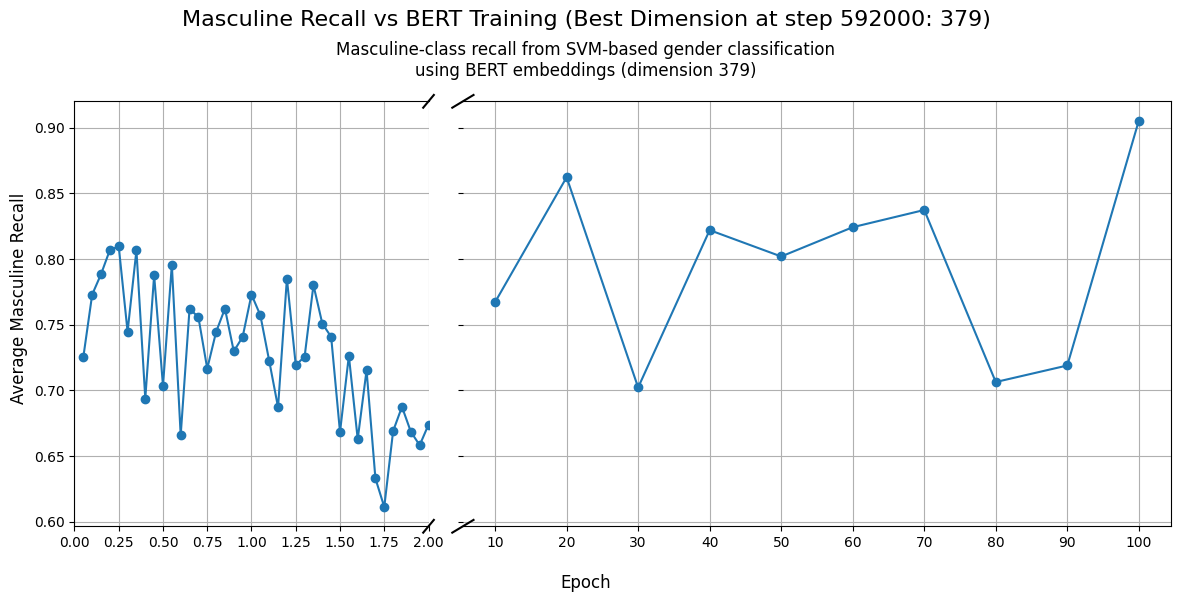

In [6]:
import json
import matplotlib.pyplot as plt

# === Load data ===
with open('results_per_dimension.json', 'r') as f:
    data = json.load(f)

# === Constants ===
steps_per_epoch = 5920
target_step = 592000

# === Step 1: Find the checkpoint at step 592000 ===
target_entry = next((e for e in data if e['checkpoint'] == target_step), None)

if target_entry is None:
    raise ValueError(f"Checkpoint {target_step} not found in data.")

# === Step 2: Find the best-performing dimension based on Masculine recall ===
best_dim = None
best_recall = -1

for dim in target_entry.get("dimensions", []):
    fold_recalls = [
        fold["classification_report"]["Masculine"]["recall"]
        for fold in dim["folds"]
    ]
    avg_recall = sum(fold_recalls) / len(fold_recalls)
    
    if avg_recall > best_recall:
        best_recall = avg_recall
        best_dim = dim["dimension"]

print(f"Best dimension by Masculine recall at step {target_step}: {best_dim} (Recall: {best_recall:.3f})")

# === Step 3: Collect recall over time for that dimension ===
x_left, y_left = [], []
x_right, y_right = [], []

for entry in data:
    step = entry['checkpoint']
    
    dim_data = next((d for d in entry.get("dimensions", []) if d["dimension"] == best_dim), None)
    
    if dim_data:
        fold_recalls = [
            fold["classification_report"]["Masculine"]["recall"]
            for fold in dim_data["folds"]
        ]
        avg_recall = sum(fold_recalls) / len(fold_recalls)
        
        if step <= 11840:
            percent = step / steps_per_epoch
            x_left.append(percent)
            y_left.append(avg_recall)
        elif step <= 592000:
            epoch = step // steps_per_epoch
            if epoch % 10 == 0 or step == target_step:
                x_right.append(epoch)
                y_right.append(avg_recall)

# === Step 4: Plot ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True, gridspec_kw={'width_ratios': [1, 2]})

# Left: early training (percentage of first 2 epochs)
ax1.plot(x_left, y_left, marker='o')
ax1.grid(True)
ax1.set_xlim(0, 2)

# Right: epochs every 10 (plus the target_step epoch)
ax2.plot(x_right, y_right, marker='o')
ax2.grid(True)
ax2.set_xticks(x_right)

# Break axis visuals
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.tick_params(labelright=False)
ax2.tick_params(labelleft=False)

# Titles
fig.suptitle(f'Masculine Recall vs BERT Training (Best Dimension at step {target_step}: {best_dim})\n\n', fontsize=16)
fig.text(0.5, 0.87, 
         f'Masculine-class recall from SVM-based gender classification\nusing BERT embeddings (dimension {best_dim})',
         ha='center', fontsize=12)
fig.supxlabel('Epoch')
fig.supylabel('Average Masculine Recall')

# Cut marks
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

plt.tight_layout()
plt.show()


Top 5 dimensions at step 592000 by Masculine recall:
 - Dimension 379: Recall 0.905
 - Dimension 284: Recall 0.898
 - Dimension 56: Recall 0.896
 - Dimension 469: Recall 0.896
 - Dimension 444: Recall 0.885
 - Dimension 494: Recall 0.882
 - Dimension 599: Recall 0.878
 - Dimension 455: Recall 0.877
 - Dimension 358: Recall 0.872
 - Dimension 334: Recall 0.871


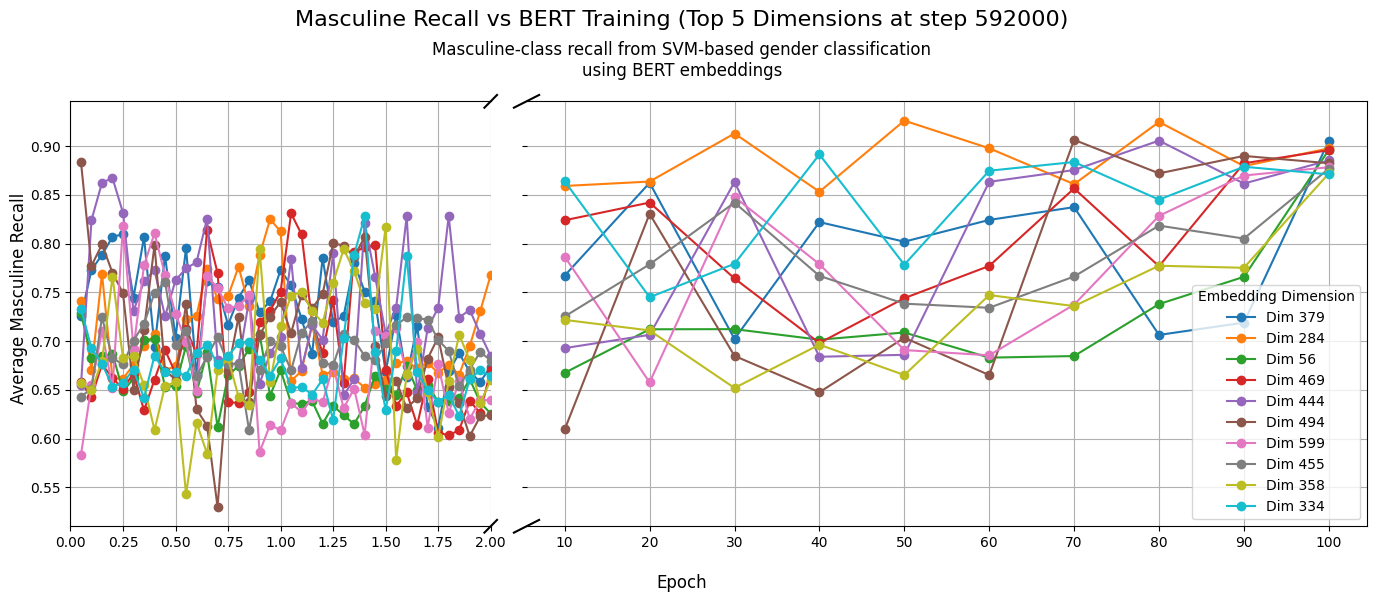

In [8]:
import json
import matplotlib.pyplot as plt

# === Load data ===
with open('results_per_dimension.json', 'r') as f:
    data = json.load(f)

# === Constants ===
steps_per_epoch = 5920
target_step = 592000

# === Step 1: Find the checkpoint at step 592000 ===
target_entry = next((e for e in data if e['checkpoint'] == target_step), None)

if target_entry is None:
    raise ValueError(f"Checkpoint {target_step} not found in data.")

# === Step 2: Find the top 5 dimensions based on Masculine recall ===
dim_recalls = []

for dim in target_entry.get("dimensions", []):
    fold_recalls = [
        fold["classification_report"]["Masculine"]["recall"]
        for fold in dim["folds"]
    ]
    avg_recall = sum(fold_recalls) / len(fold_recalls)
    dim_recalls.append((dim["dimension"], avg_recall))

# Sort and get top 5
top_dims = sorted(dim_recalls, key=lambda x: x[1], reverse=True)[:10]
print("Top 5 dimensions at step 592000 by Masculine recall:")
for dim_id, score in top_dims:
    print(f" - Dimension {dim_id}: Recall {score:.3f}")

# === Step 3: Collect recall over time for each top dimension ===
dimension_traces = {dim_id: {'x_left': [], 'y_left': [], 'x_right': [], 'y_right': []} for dim_id, _ in top_dims}

for entry in data:
    step = entry['checkpoint']
    epoch = step // steps_per_epoch

    for dim_id, _ in top_dims:
        dim_data = next((d for d in entry.get("dimensions", []) if d["dimension"] == dim_id), None)
        if dim_data:
            fold_recalls = [
                fold["classification_report"]["Masculine"]["recall"]
                for fold in dim_data["folds"]
            ]
            avg_recall = sum(fold_recalls) / len(fold_recalls)

            if step <= 11840:
                percent = step / steps_per_epoch
                dimension_traces[dim_id]['x_left'].append(percent)
                dimension_traces[dim_id]['y_left'].append(avg_recall)
            elif step <= 592000:
                if epoch % 10 == 0 or step == target_step:
                    dimension_traces[dim_id]['x_right'].append(epoch)
                    dimension_traces[dim_id]['y_right'].append(avg_recall)

# === Step 4: Plot ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'width_ratios': [1, 2]})

# Color cycle for lines
colors = plt.cm.tab10.colors

# Plot each dimension
for idx, (dim_id, _) in enumerate(top_dims):
    trace = dimension_traces[dim_id]
    ax1.plot(trace['x_left'], trace['y_left'], label=f'Dim {dim_id}', color=colors[idx % 10], marker='o')
    ax2.plot(trace['x_right'], trace['y_right'], label=f'Dim {dim_id}', color=colors[idx % 10], marker='o')

# Axis formatting
ax1.grid(True)
ax2.grid(True)
ax1.set_xlim(0, 2)
ax2.set_xticks(sorted(set(epoch for trace in dimension_traces.values() for epoch in trace['x_right'])))

# Break axis visuals
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.tick_params(labelright=False)
ax2.tick_params(labelleft=False)

# Titles
fig.suptitle(f'Masculine Recall vs BERT Training (Top 5 Dimensions at step {target_step})\n\n', fontsize=16)
fig.text(0.5, 0.87, 
         'Masculine-class recall from SVM-based gender classification\nusing BERT embeddings',
         ha='center', fontsize=12)
fig.supxlabel('Epoch')
fig.supylabel('Average Masculine Recall')

# Cut marks
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

# Legend and layout
ax2.legend(title="Embedding Dimension", loc='lower right')
plt.tight_layout()
plt.show()


Best dimension by Feminine recall at step 592000: 211 (Recall: 0.754)


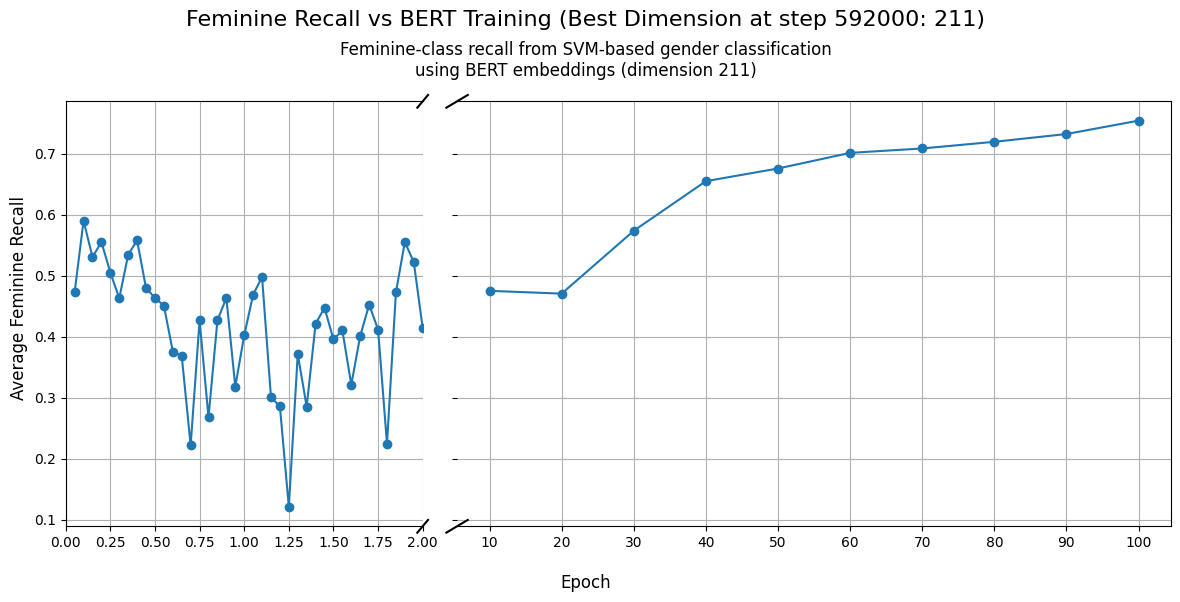

In [9]:
import json
import matplotlib.pyplot as plt

# === Load data ===
with open('results_per_dimension.json', 'r') as f:
    data = json.load(f)

# === Constants ===
steps_per_epoch = 5920
target_step = 592000

# === Step 1: Find the checkpoint at step 592000 ===
target_entry = next((e for e in data if e['checkpoint'] == target_step), None)

if target_entry is None:
    raise ValueError(f"Checkpoint {target_step} not found in data.")

# === Step 2: Find the best-performing dimension based on Feminine recall ===
best_dim = None
best_recall = -1

for dim in target_entry.get("dimensions", []):
    fold_recalls = [
        fold["classification_report"]["Feminine"]["recall"]
        for fold in dim["folds"]
    ]
    avg_recall = sum(fold_recalls) / len(fold_recalls)
    
    if avg_recall > best_recall:
        best_recall = avg_recall
        best_dim = dim["dimension"]

print(f"Best dimension by Feminine recall at step {target_step}: {best_dim} (Recall: {best_recall:.3f})")

# === Step 3: Collect recall over time for that dimension ===
x_left, y_left = [], []
x_right, y_right = [], []

for entry in data:
    step = entry['checkpoint']
    
    dim_data = next((d for d in entry.get("dimensions", []) if d["dimension"] == best_dim), None)
    
    if dim_data:
        fold_recalls = [
            fold["classification_report"]["Feminine"]["recall"]
            for fold in dim_data["folds"]
        ]
        avg_recall = sum(fold_recalls) / len(fold_recalls)
        
        if step <= 11840:
            percent = step / steps_per_epoch
            x_left.append(percent)
            y_left.append(avg_recall)
        elif step <= 592000:
            epoch = step // steps_per_epoch
            if epoch % 10 == 0 or step == target_step:
                x_right.append(epoch)
                y_right.append(avg_recall)

# === Step 4: Plot ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True, gridspec_kw={'width_ratios': [1, 2]})

# Left: early training (percentage of first 2 epochs)
ax1.plot(x_left, y_left, marker='o')
ax1.grid(True)
ax1.set_xlim(0, 2)

# Right: epochs every 10 (plus the target_step epoch)
ax2.plot(x_right, y_right, marker='o')
ax2.grid(True)
ax2.set_xticks(x_right)

# Break axis visuals
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.tick_params(labelright=False)
ax2.tick_params(labelleft=False)

# Titles
fig.suptitle(f'Feminine Recall vs BERT Training (Best Dimension at step {target_step}: {best_dim})\n\n', fontsize=16)
fig.text(0.5, 0.87, 
         f'Feminine-class recall from SVM-based gender classification\nusing BERT embeddings (dimension {best_dim})',
         ha='center', fontsize=12)
fig.supxlabel('Epoch')
fig.supylabel('Average Feminine Recall')

# Cut marks
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

plt.tight_layout()
plt.show()


Top 5 dimensions at step 592000 by Feminine recall:
 - Dimension 211: Recall 0.754
 - Dimension 399: Recall 0.700
 - Dimension 270: Recall 0.696
 - Dimension 437: Recall 0.688
 - Dimension 26: Recall 0.676
 - Dimension 604: Recall 0.675
 - Dimension 442: Recall 0.672
 - Dimension 336: Recall 0.666
 - Dimension 721: Recall 0.665
 - Dimension 344: Recall 0.664


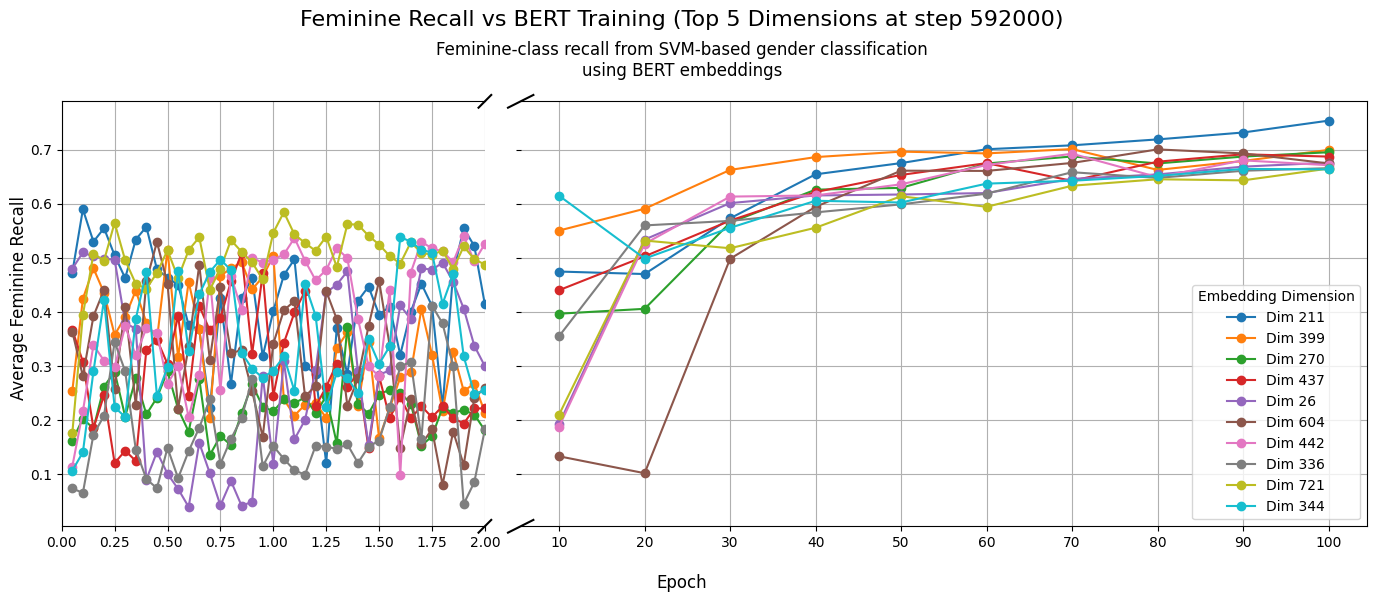

In [14]:
import json
import matplotlib.pyplot as plt

# === Load data ===
with open('results_per_dimension.json', 'r') as f:
    data = json.load(f)

# === Constants ===
steps_per_epoch = 5920
target_step = 592000

# === Step 1: Find the checkpoint at step 592000 ===
target_entry = next((e for e in data if e['checkpoint'] == target_step), None)

if target_entry is None:
    raise ValueError(f"Checkpoint {target_step} not found in data.")

# === Step 2: Find the top 5 dimensions based on Feminine recall ===
dim_recalls = []

for dim in target_entry.get("dimensions", []):
    fold_recalls = [
        fold["classification_report"]["Feminine"]["recall"]
        for fold in dim["folds"]
    ]
    avg_recall = sum(fold_recalls) / len(fold_recalls)
    dim_recalls.append((dim["dimension"], avg_recall))

# Sort and get top 5
top_dims = sorted(dim_recalls, key=lambda x: x[1], reverse=True)[:10]
print("Top 5 dimensions at step 592000 by Feminine recall:")
for dim_id, score in top_dims:
    print(f" - Dimension {dim_id}: Recall {score:.3f}")

# === Step 3: Collect recall over time for each top dimension ===
dimension_traces = {dim_id: {'x_left': [], 'y_left': [], 'x_right': [], 'y_right': []} for dim_id, _ in top_dims}

for entry in data:
    step = entry['checkpoint']
    epoch = step // steps_per_epoch

    for dim_id, _ in top_dims:
        dim_data = next((d for d in entry.get("dimensions", []) if d["dimension"] == dim_id), None)
        if dim_data:
            fold_recalls = [
                fold["classification_report"]["Feminine"]["recall"]
                for fold in dim_data["folds"]
            ]
            avg_recall = sum(fold_recalls) / len(fold_recalls)

            if step <= 11840:
                percent = step / steps_per_epoch
                dimension_traces[dim_id]['x_left'].append(percent)
                dimension_traces[dim_id]['y_left'].append(avg_recall)
            elif step <= 592000:
                if epoch % 10 == 0 or step == target_step:
                    dimension_traces[dim_id]['x_right'].append(epoch)
                    dimension_traces[dim_id]['y_right'].append(avg_recall)

# === Step 4: Plot ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'width_ratios': [1, 2]})

# Color cycle for lines
colors = plt.cm.tab10.colors

# Plot each dimension
for idx, (dim_id, _) in enumerate(top_dims):
    trace = dimension_traces[dim_id]
    ax1.plot(trace['x_left'], trace['y_left'], label=f'Dim {dim_id}', color=colors[idx % 10], marker='o')
    ax2.plot(trace['x_right'], trace['y_right'], label=f'Dim {dim_id}', color=colors[idx % 10], marker='o')

# Axis formatting
ax1.grid(True)
ax2.grid(True)
ax1.set_xlim(0, 2)
ax2.set_xticks(sorted(set(epoch for trace in dimension_traces.values() for epoch in trace['x_right'])))

# Break axis visuals
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.tick_params(labelright=False)
ax2.tick_params(labelleft=False)

# Titles
fig.suptitle(f'Feminine Recall vs BERT Training (Top 5 Dimensions at step {target_step})\n\n', fontsize=16)
fig.text(0.5, 0.87, 
         'Feminine-class recall from SVM-based gender classification\nusing BERT embeddings',
         ha='center', fontsize=12)
fig.supxlabel('Epoch')
fig.supylabel('Average Feminine Recall')

# Cut marks
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

# Legend and layout
ax2.legend(title="Embedding Dimension", loc='lower right')
plt.tight_layout()
plt.show()


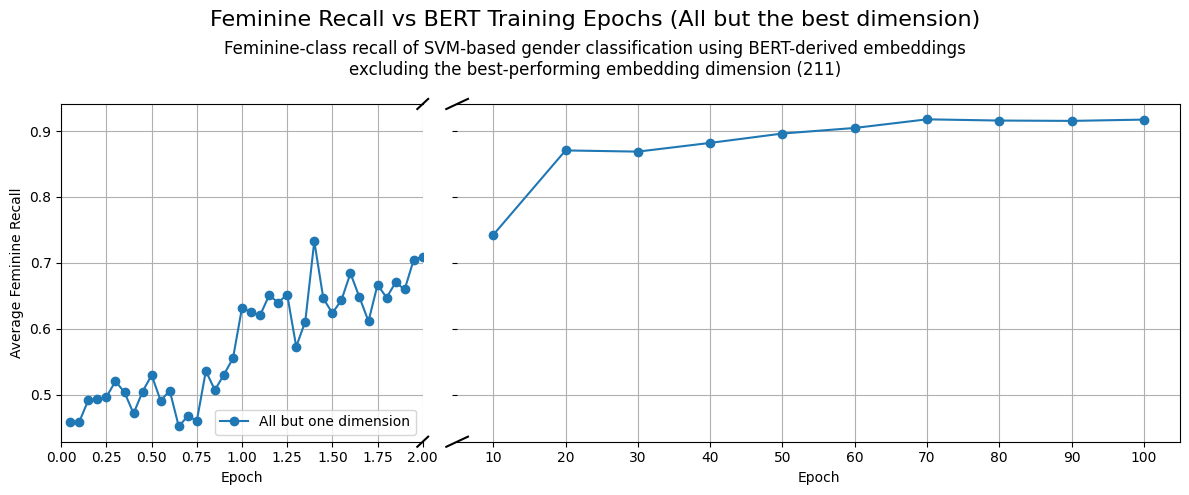

In [15]:
import json
import matplotlib.pyplot as plt

# Load the data
with open('results_allbutone.json', 'r') as f:
    data = json.load(f)

steps_per_epoch = 5920
x_left, y_left = [], []
x_right, y_right = [], []

# Fill in the data
for entry in data:
    step = entry['checkpoint']
    
    # === Compute Feminine recall across folds ===
    fold_recalls = [
        fold["classification_report"]["Feminine"]["recall"]
        for fold in entry["folds"]
    ]
    recall = sum(fold_recalls) / len(fold_recalls)
    
    # Split into early and late x-axis
    if step <= 11840:
        percent = step / steps_per_epoch
        x_left.append(percent)
        y_left.append(recall)
    elif step <= 592000:
        epoch = step // steps_per_epoch
        if epoch % 10 == 0:
            x_right.append(epoch)
            y_right.append(recall)

# Set up broken axis plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True,
                               gridspec_kw={'width_ratios': [1, 2]})

# Plot lines
ax1.plot(x_left, y_left, marker='o', label="All but one dimension")
ax2.plot(x_right, y_right, marker='o')

# Set x-limits
ax1.set_xlim(0, 2)
ax2.set_xlim(min(x_right) - 5, max(x_right) + 5)

# Axes style
ax1.grid(True)
ax2.grid(True)
ax2.set_xticks(sorted(set(x_right)))
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.tick_params(labelright=False)
ax2.tick_params(labelleft=False)

# Diagonal break marks
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

# Set titles and labels
fig.suptitle('Feminine Recall vs BERT Training Epochs (All but the best dimension)\n', fontsize=16)
fig.text(0.5, 0.85, 
         'Feminine-class recall of SVM-based gender classification using BERT-derived embeddings\nexcluding the best-performing embedding dimension (211)', 
         ha='center', fontsize=12)
ax1.set_xlabel("Epoch")
ax2.set_xlabel("Epoch")
ax1.set_ylabel("Average Feminine Recall")
ax1.legend(loc='lower right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
